# LLM 기반 피드백 분류 - 최종 실험 노트북

## 이 노트북의 목적
이 노트북은 **대규모 언어 모델(LLM)**을 사용하여 고등학교 과학 수업의 동료 피드백을 7단계로 자동 분류하는 실험을 실행합니다.

## 핵심 개념 설명

### LLM (Large Language Model, 대규모 언어 모델)
- GPT-4o와 같이 대량의 텍스트 데이터로 학습된 AI 모델
- 별도의 학습(훈련) 없이 **프롬프트(지시문)만으로** 분류 수행 가능
- ML/BERT와 달리 학습 데이터가 필요하지 않아 "제로샷(Zero-shot)" 접근이 가능

### 프롬프트 엔지니어링 (Prompt Engineering)
- LLM에 전달하는 지시문을 최적화하여 분류 성능을 높이는 과정
- 본 실험에서의 프롬프트 진화:
  - **P0 (제로샷)**: 루브릭만 제공, 예시 없음 → Kappa ≈ 0.34
  - **P1~P2 (CoT + 퓨샷)**: 사고 과정 유도 + 예시 포함 → Kappa ≈ 0.53
  - **P9 (Hard Tiebreaker)**: 레이블 3/4/5 경계 구분 규칙 추가 → Kappa ≈ 0.65

### 실험 설계
- **재현성(Reproducibility)**: 동일 조건에서 3회 반복하여 결과 일관성 확인
- **일반화(Generalization)**: 다른 데이터 분할(seed)에서도 유사한 성능 유지 확인
- **비용**: 각 실행당 약 $3~5 (GPT-4o API 호출 비용)

### 7단계 피드백 코딩 체계
| 레이블 | 명칭 | 설명 |
|--------|------|------|
| 0 | 무관 | 피드백과 관련 없는 내용 |
| 1 | 평가만 | 단순 긍정/부정 평가 |
| 2 | 기술 | 구체적 내용 기술 |
| 3 | 문제 지적 | 오류나 문제점 지적 |
| 4 | 해결 방향 | 개선 방향 제안 |
| 5 | 구체적 대안 | 구체적 수정 방안 제시 |
| 6 | 대안적 관점 | 새로운 관점이나 접근법 제안 |

# LLM 분류 모델 재현성 및 일반화 실험

## 실험 목적
1. **재현성(Reproducibility)**: 동일 모델+프롬프트로 동일 데이터를 3회 예측했을 때 결과가 일치하는가?
2. **일반화(Generalization)**: 다른 데이터 split(seed)에서도 유사한 성능을 보이는가?

## 실험 설계
- **데이터**: 3개 seed (42, 43, 44)로 분할된 test set
- **모델**: GPT-4o, Solar-Pro3 (2개)
- **프롬프트**: P0_zero-shot_rubric, P2_few-shot_cot_v3, P2_few-shot_cot_v6 (3개)
- **반복**: 각 조합당 3회
- **총 실험 수**: 3 seeds × 2 models × 3 prompts × 3 repeats = 54개

## 워크플로우
```
각 (seed, model, prompt) 조합에 대해:
1. 해당 seed의 test set 로드
2. 3회 반복 예측 → 재현성 측정 (3회 예측 일치율)
3. 성능 평가 (Accuracy, F1 Macro, Kappa)
4. 다른 seed와 비교 → 일반화 분석
```

---
## 1. 환경 설정

아래 셀에서는 실험에 필요한 라이브러리를 불러오고 기본 설정을 초기화합니다.
- `src/` 디렉토리의 모듈들: 모델 래퍼, 프롬프트 로더, 실험 실행기 등
- `Config()`: API 키 로드, 디렉토리 경로 설정, 반복 횟수(3회) 등 전체 실험 설정
- `set_seed(42)`: 데이터 분할의 재현성을 보장하기 위한 랜덤 시드 고정

In [10]:
import sys
import os
from pathlib import Path
from datetime import datetime
import json
import warnings
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# src 디렉토리를 path에 추가
src_path = Path.cwd().parent / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from config import Config, ModelConfig
from prompt_loader import PromptLoader
from experiment import ExperimentRunner
from utils import set_seed, compute_metrics

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 설정 초기화
config = Config()
config.n_repeats = 3  # 반복 횟수 고정
set_seed(config.random_seed)

# 결과 저장 디렉토리
OUTPUT_DIR = config.results_dir / 'final_experiment'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'reproducibility').mkdir(exist_ok=True)
(OUTPUT_DIR / 'generalization').mkdir(exist_ok=True)
(OUTPUT_DIR / 'summary').mkdir(exist_ok=True)

print('환경 설정 완료!')
print(f'반복 횟수: {config.n_repeats}')
print(f'Random Seed: {config.random_seed}')
print(f"OPENAI_API_KEY 설정됨: {bool(os.getenv('OPENAI_API_KEY'))}")
print(f"UPSTAGE_API_KEY 설정됨: {bool(os.getenv('UPSTAGE_API_KEY'))}")
print(f'결과 저장 디렉토리: {OUTPUT_DIR}')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


환경 설정 완료!
반복 횟수: 3
Random Seed: 42
OPENAI_API_KEY 설정됨: True
UPSTAGE_API_KEY 설정됨: True
결과 저장 디렉토리: <PROJECT_ROOT>/01_Analysis/03_LLM/results/final_experiment


In [11]:
# (옵션) API 설정
os.environ.setdefault('OPENAI_MAX_CONCURRENCY', '2')
os.environ.setdefault('UPSTAGE_MAX_CONCURRENCY', '2')
os.environ.setdefault('OPENAI_RATE_LIMIT_DELAY', '0.2')
os.environ.setdefault('UPSTAGE_RATE_LIMIT_DELAY', '0.8')
os.environ.setdefault('OPENAI_MAX_RETRIES', '4')
os.environ.setdefault('UPSTAGE_MAX_RETRIES', '4')

'4'

---
## 2. 데이터 로드 (Seed별 Test Set)

테스트 데이터를 3개의 서로 다른 랜덤 시드(42, 43, 44)로 분할합니다.
- **시드(Seed)**: 데이터를 무작위로 나눌 때 사용하는 초기값. 같은 시드 = 같은 분할
- **일반화 검증**: 여러 시드로 테스트하면 "우연히 좋은 분할"에 의한 성능 과대평가를 방지
- 각 시드별 테스트셋은 약 416개 피드백 텍스트를 포함

In [12]:
# 데이터 경로 설정
DATA_PATH = config.base_dir.parent / 'data' / 'feedback_data.xlsx'
SEEDS = [42, 43, 44]

# 컬럼명 설정
TEXT_COLUMN = 'feedback_text'
LABEL_COLUMN = 'label'
ID_COLUMN = 'id'

# Seed별 테스트 데이터 로드
test_datasets = {}
for seed in SEEDS:
    all_df = pd.read_excel(DATA_PATH)
    test_df = all_df[all_df[f'split_seed{seed}'] == 'test'].reset_index(drop=True)
    test_datasets[seed] = test_df
    print(f"Seed {seed}: Test={test_df.shape}")

print(f"\n컬럼: {test_datasets[42].columns.tolist()}")

Seed 42: Test=(416, 3)
Seed 43: Test=(416, 3)
Seed 44: Test=(416, 3)

컬럼: ['id', 'feedback_text', 'label']


In [13]:
# 데이터 분포 확인
print("="*60)
print("Label 분포 비교 (Test Set)")
print("="*60)

for seed in SEEDS:
    test_dist = test_datasets[seed][LABEL_COLUMN].value_counts().sort_index()
    print(f"\nSeed {seed}: {dict(test_dist)}")
    print(f"  총 샘플: {len(test_datasets[seed])}개")

Label 분포 비교 (Test Set)

Seed 42: {0: 12, 1: 103, 2: 57, 3: 146, 4: 36, 5: 55, 6: 7}
  총 샘플: 416개

Seed 43: {0: 12, 1: 103, 2: 57, 3: 146, 4: 36, 5: 55, 6: 7}
  총 샘플: 416개

Seed 44: {0: 12, 1: 103, 2: 57, 3: 146, 4: 36, 5: 55, 6: 7}
  총 샘플: 416개


---
## 3. 모델 및 프롬프트 설정

### 실험 대상 모델
- **GPT-4o**: OpenAI의 플래그십 모델 (가장 높은 성능 기대, API 비용 발생)
- **Solar-Pro3**: Upstage의 한국어 지원 모델 (비교 대상)

### 프롬프트 버전
각 프롬프트는 `prompts/` 디렉토리의 마크다운(.md) 파일로 관리됩니다.
- **P0**: 제로샷(Zero-shot) - 루브릭만 제공
- **P1~P2**: 퓨샷(Few-shot) + CoT(Chain-of-Thought) - 예시와 단계적 사고 유도
- **P9**: Hard Tiebreaker - 경계 레이블(3/4/5) 구분 규칙 추가

### API 비용 주의
- GPT-4o: 입력 $2.50/1M토큰, 출력 $10.00/1M토큰
- 아래 셀에서 `OPENAI_MAX_CONCURRENCY`로 동시 요청 수를 제어하여 비용 관리

In [5]:
# 실험 모델 설정
experiment_models = [
    ModelConfig(
        model_id='gpt-4o-mini',
        model_type='openai',
        display_name='GPT-4o mini',
        temperature=0.0,
        max_tokens=50
    ),
    ModelConfig(
        model_id='solar-pro3',
        model_type='upstage',
        display_name='Solar-Pro3',
        temperature=0,
        max_tokens=50,
        reasoning_effort='low'
    ),
    ModelConfig(
        model_id='gpt-4o',
        model_type='openai',
        display_name='GPT-4o',
        temperature=0.0,
        max_tokens=50
    ),
]

print('실험 모델:')
for m in experiment_models:
    print(f'  - {m.display_name} ({m.model_id})')

실험 모델:
  - GPT-4o mini (gpt-4o-mini)
  - Solar-Pro3 (solar-pro3)
  - GPT-4o (gpt-4o)


In [14]:
# 실험 모델 설정 2 - 일부만 하고 싶을 때
experiment_models = [
    ModelConfig(
        model_id='gpt-4o',
        model_type='openai',
        display_name='GPT-4o',
        temperature=0.0,
        max_tokens=50
    ),
]

print('실험 모델:')
for m in experiment_models:
    print(f'  - {m.display_name} ({m.model_id})')

실험 모델:
  - GPT-4o (gpt-4o)


In [15]:
# 프롬프트 설정
prompt_loader = PromptLoader(config.prompts_dir)
prompt_versions = prompt_loader.list_versions()

print('사용할 프롬프트 버전:')
for v in prompt_versions:
    print(f'  - {v}')

print(f'\n총 프롬프트 수: {len(prompt_versions)}개')

사용할 프롬프트 버전:
  - P2_few-shot_cot_v6
  - P3_CoT_Few_Context

총 프롬프트 수: 2개


---
## 4. 실험 함수 정의

아래 함수는 단일 실험(1모델 × 1프롬프트 × 1테스트셋)을 실행합니다.
- 각 피드백 텍스트를 프롬프트 템플릿에 삽입하여 LLM API를 호출
- LLM 응답에서 레이블(0~6)을 파싱하고 성능 지표를 계산
- 파싱 실패(n_fail): LLM이 유효한 JSON 형식으로 응답하지 않은 경우

In [16]:
def run_single_prediction(runner, model, prompt, test_df, model_config):
    """
    단일 예측 실행
    
    Returns:
        predictions: list of predicted labels
        metrics: dict of evaluation metrics
        parsed_ok_list: list of parsing success flags
    """
    result = runner.run_single_experiment(
        model=model,
        prompt=prompt,
        test_df=test_df,
        model_config=model_config
    )
    
    return result.predictions, result.metrics, result.parsed_ok_list

# 이부분에서 n_repeats 값을 바꾸자. 기본 3
def run_reproducibility_test(runner, model, prompt, test_df, model_config, n_repeats=3):
    """
    재현성 테스트: 동일 데이터에 대해 n회 예측
    
    Returns:
        all_predictions: list of prediction arrays (n_repeats x n_samples)
        all_metrics: list of metrics dicts
        agreement_rate: 모든 예측이 일치하는 샘플 비율
        disagreement_indices: 불일치 샘플 인덱스
    """
    all_predictions = []
    all_metrics = []
    all_parsed_ok = []
    
    for i in range(n_repeats):
        preds, metrics, parsed_ok = run_single_prediction(
            runner, model, prompt, test_df, model_config
        )
        all_predictions.append(preds)
        all_metrics.append(metrics)
        all_parsed_ok.append(parsed_ok)
        
        print(f"      Run {i+1}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1_macro']:.4f}")
    
    # 일치율 계산 (None은 -1로 변환하여 비교)
    predictions_array = np.array([
        [p if p is not None else -1 for p in preds]
        for preds in all_predictions
    ])
    
    agreement = np.all(predictions_array == predictions_array[0], axis=0)
    agreement_rate = agreement.mean()
    disagreement_indices = np.where(~agreement)[0]
    
    return all_predictions, all_metrics, all_parsed_ok, agreement_rate, disagreement_indices

print("실험 함수 정의 완료")

실험 함수 정의 완료


---
## 5. 전체 실험 실행

**주의**: 이 섹션은 LLM API를 대량 호출합니다.
- 총 실험 수: 3 seeds × 2 models × 3~4 prompts × 3 repeats = 54~72개
- 예상 비용: 약 $60~120 (GPT-4o 기준)
- `RUN_EXPERIMENT = False`로 변경하면 API 호출을 건너뛰고 저장된 결과를 사용합니다.

각 (seed, 모델, 프롬프트) 조합에 대해 3회 반복 예측을 수행하고,
재현성(3회 일치율)과 성능(Accuracy, F1, Kappa)을 측정합니다.

In [17]:
# 실험 설정
N_REPEATS = 1

# 결과 저장용 리스트
all_reproducibility_results = []  # 재현성 결과 (same seed)
all_detailed_predictions = []     # 상세 예측 결과

# 총 조합 수
total_combinations = len(SEEDS) * len(experiment_models) * len(prompt_versions)

print("="*70)
print("LLM 재현성 및 일반화 실험 시작")
print("="*70)
print(f"Seeds: {SEEDS}")
print(f"Models: {[m.display_name for m in experiment_models]}")
print(f"Prompts: {prompt_versions}")
print(f"Repeats per combination: {N_REPEATS}")
print(f"총 조합: {total_combinations}개")
print(f"총 API 호출: {total_combinations * N_REPEATS * len(test_datasets[42])}회 (예상)")
print("="*70)

LLM 재현성 및 일반화 실험 시작
Seeds: [42, 43, 44]
Models: ['GPT-4o']
Prompts: ['P2_few-shot_cot_v6', 'P3_CoT_Few_Context']
Repeats per combination: 1
총 조합: 6개
총 API 호출: 2496회 (예상)


In [19]:
# 실험 실행 여부
RUN_EXPERIMENT = True  # False로 변경하면 실험 건너뜀

if RUN_EXPERIMENT:
    # 실험 실행기 초기화
    runner = ExperimentRunner(config)
    
    # 전체 진행률
    pbar = tqdm(total=total_combinations, desc="전체 진행률")
    
    for model_config in experiment_models:
        print(f"\n{'#'*70}")
        print(f"# Model: {model_config.display_name}")
        print(f"{'#'*70}")
        
        try:
            model = runner.load_model(model_config)
        except Exception as e:
            print(f"  모델 로드 실패: {e}")
            pbar.update(len(SEEDS) * len(prompt_versions))
            continue
        
        for prompt_version in prompt_versions:
            print(f"\n  [프롬프트] {prompt_version}")
            
            try:
                prompt = prompt_loader.load(prompt_version)
            except Exception as e:
                print(f"    프롬프트 로드 실패: {e}")
                pbar.update(len(SEEDS))
                continue
            
            for test_seed in SEEDS:
                print(f"\n    [Seed {test_seed}]")
                
                test_df = test_datasets[test_seed]
                y_true = test_df[LABEL_COLUMN].tolist()
                sample_ids = test_df[ID_COLUMN].tolist() if ID_COLUMN in test_df.columns else test_df.index.tolist()
                
                try:
                    # 재현성 테스트 (3회 반복)
                    all_preds, all_metrics, all_parsed_ok, agreement_rate, disagree_idx = run_reproducibility_test(
                        runner, model, prompt, test_df, model_config, n_repeats=N_REPEATS
                    )
                    
                    # 평균 성능 계산
                    avg_acc = np.mean([m['accuracy'] for m in all_metrics])
                    avg_f1 = np.mean([m['f1_macro'] for m in all_metrics])
                    avg_kappa = np.mean([m['kappa'] for m in all_metrics])
                    
                    std_acc = np.std([m['accuracy'] for m in all_metrics])
                    std_f1 = np.std([m['f1_macro'] for m in all_metrics])
                    std_kappa = np.std([m['kappa'] for m in all_metrics])
                    
                    # 재현성 결과 저장
                    rep_result = {
                        'Model': model_config.display_name,
                        'Prompt': prompt_version,
                        'Test_Seed': test_seed,
                        'N_Samples': len(test_df),
                        'Agreement_Rate': agreement_rate,
                        'Disagreement_Count': len(disagree_idx),
                        'Acc_Mean': avg_acc,
                        'Acc_Std': std_acc,
                        'F1_Mean': avg_f1,
                        'F1_Std': std_f1,
                        'Kappa_Mean': avg_kappa,
                        'Kappa_Std': std_kappa,
                        # 개별 run 결과
                        'Acc_Run1': all_metrics[0]['accuracy'],
                        'Acc_Run2': all_metrics[1]['accuracy'],
                        'Acc_Run3': all_metrics[2]['accuracy'],
                        'F1_Run1': all_metrics[0]['f1_macro'],
                        'F1_Run2': all_metrics[1]['f1_macro'],
                        'F1_Run3': all_metrics[2]['f1_macro'],
                    }
                    all_reproducibility_results.append(rep_result)
                    
                    # 상세 예측 저장
                    for run_idx, (preds, parsed_ok) in enumerate(zip(all_preds, all_parsed_ok)):
                        for i, (sid, y_t, y_p, p_ok) in enumerate(zip(sample_ids, y_true, preds, parsed_ok)):
                            detailed = {
                                'Model': model_config.display_name,
                                'Prompt': prompt_version,
                                'Test_Seed': test_seed,
                                'Run': run_idx + 1,
                                'Sample_ID': sid,
                                'Y_True': y_t,
                                'Y_Pred': y_p if y_p is not None else 'NA',
                                'Parsed_OK': p_ok
                            }
                            all_detailed_predictions.append(detailed)
                    
                    print(f"      → Agreement: {agreement_rate:.4f}, Avg F1: {avg_f1:.4f}")
                    
                except Exception as e:
                    print(f"      실험 실패: {e}")
                
                pbar.update(1)
    
    pbar.close()
    print("\n" + "="*70)
    print("전체 실험 완료!")
    print("="*70)
else:
    print("RUN_EXPERIMENT = False (실험 건너뜀)")


전체 진행률:   0%|          | 0/6 [47:59<?, ?it/s]



######################################################################
# Model: GPT-4o
######################################################################
[OpenAI] gpt-4o 초기화 완료

  [프롬프트] P2_few-shot_cot_v6

    [Seed 42]


gpt-4o: 100%|██████████| 416/416 [03:17<00:00,  2.11it/s]



      Run 1: Acc=0.6659, F1=0.6425
      실험 실패: list index out of range

    [Seed 43]


gpt-4o: 100%|██████████| 416/416 [03:16<00:00,  2.12it/s]



...

      Run 1: Acc=0.6538, F1=0.6914
      실험 실패: list index out of range

    [Seed 43]


gpt-4o: 100%|██████████| 416/416 [03:02<00:00,  2.27it/s]



      Run 1: Acc=0.6322, F1=0.6546
      실험 실패: list index out of range

    [Seed 44]


gpt-4o: 100%|██████████| 416/416 [03:09<00:00,  2.20it/s]

전체 진행률: 100%|██████████| 6/6 [19:06<00:00, 191.08s/it]

      Run 1: Acc=0.6274, F1=0.6696
      실험 실패: list index out of range

전체 실험 완료!


---
## 6. 결과 저장

실험 결과를 CSV 파일로 저장합니다.
- `reproducibility_df`: 재현성 지표 (3회 일치율, Fleiss' Kappa 등)
- `all_detailed_predictions`: 샘플별 예측 상세 (실제 레이블, 예측 레이블, 원본 응답)
- 타임스탬프 포함 파일명으로 이전 결과를 덮어쓰지 않음

In [20]:
# DataFrame 변환
if all_reproducibility_results:
    reproducibility_df = pd.DataFrame(all_reproducibility_results)
    print(f"재현성 결과: {reproducibility_df.shape}")
    display(reproducibility_df.head())
else:
    print("결과가 없습니다. 실험을 먼저 실행하세요.")

결과가 없습니다. 실험을 먼저 실행하세요.


In [11]:
# CSV 저장
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 재현성 결과 저장
    repro_path = OUTPUT_DIR / 'summary' / f'reproducibility_results_{timestamp}.csv'
    reproducibility_df.to_csv(repro_path, index=False, encoding='utf-8-sig')
    print(f"재현성 결과 저장: {repro_path}")
    
    # 상세 예측 저장
    if all_detailed_predictions:
        detailed_df = pd.DataFrame(all_detailed_predictions)
        detailed_path = OUTPUT_DIR / 'summary' / f'detailed_predictions_{timestamp}.csv'
        detailed_df.to_csv(detailed_path, index=False, encoding='utf-8-sig')
        print(f"상세 예측 저장: {detailed_path}")
        print(f"  - 총 {len(detailed_df)}개 레코드")

재현성 결과 저장: <PROJECT_ROOT>/01_Analysis/03_LLM/results/final_experiment/summary/reproducibility_results_20260201_030925.csv
상세 예측 저장: <PROJECT_ROOT>/01_Analysis/03_LLM/results/final_experiment/summary/detailed_predictions_20260201_030925.csv
  - 총 33696개 레코드


---
## 7. 재현성 분석

LLM의 재현성(Reproducibility)을 분석합니다.
- **3회 일치율**: 동일 입력에 대해 3회 예측이 모두 같은 비율
- **Fleiss' Kappa**: 3명 이상의 평가자 간 일치도 (여기서는 3회 반복을 평가자로 간주)
- **Krippendorff's Alpha**: 신뢰도 계수 (결측값 허용)
- temperature=0 설정으로 대부분 높은 재현성을 보이지만, API 서버 상태에 따라 약간의 변동 가능

In [12]:
# 재현성 요약
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    print("="*70)
    print("재현성 분석 결과")
    print("="*70)
    
    # 전체 통계
    print(f"\n[전체 통계]")
    print(f"  평균 일치율: {reproducibility_df['Agreement_Rate'].mean():.4f}")
    print(f"  최소 일치율: {reproducibility_df['Agreement_Rate'].min():.4f}")
    print(f"  최대 일치율: {reproducibility_df['Agreement_Rate'].max():.4f}")
    
    # 모델별 재현성
    print(f"\n[모델별 평균 일치율]")
    model_repro = reproducibility_df.groupby('Model')['Agreement_Rate'].agg(['mean', 'std']).round(4)
    print(model_repro.to_string())
    
    # 프롬프트별 재현성
    print(f"\n[프롬프트별 평균 일치율]")
    prompt_repro = reproducibility_df.groupby('Prompt')['Agreement_Rate'].agg(['mean', 'std']).round(4)
    print(prompt_repro.to_string())

재현성 분석 결과

[전체 통계]
  평균 일치율: 0.9342
  최소 일치율: 0.8774
  최대 일치율: 0.9688

[모델별 평균 일치율]
               mean     std
Model                      
GPT-4o       0.9418  0.0153
GPT-4o mini  0.9509  0.0117
Solar-Pro3   0.9100  0.0192

[프롬프트별 평균 일치율]
                       mean     std
Prompt                             
P0_zero-shot_rubric  0.9284  0.0299
P2_few-shot_cot_v3   0.9404  0.0210
P2_few-shot_cot_v6   0.9338  0.0188


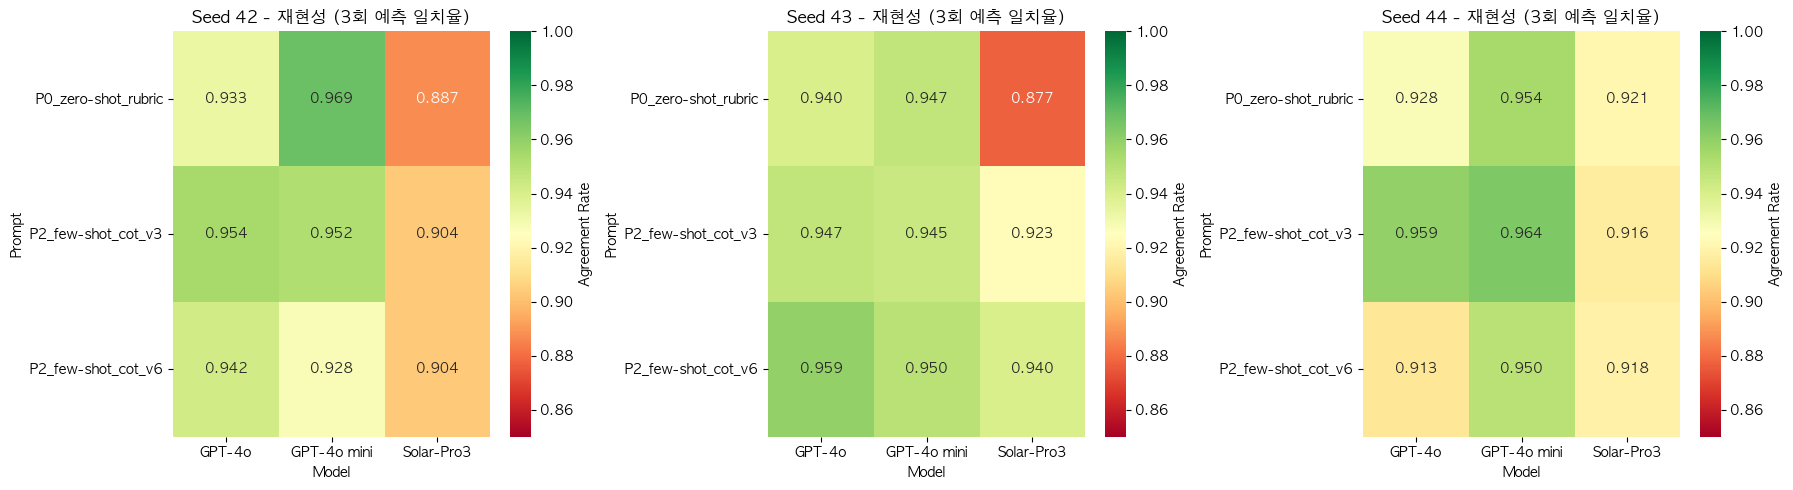

In [13]:
# 재현성 히트맵
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, seed in enumerate(SEEDS):
        subset = reproducibility_df[reproducibility_df['Test_Seed'] == seed]
        pivot = subset.pivot(index='Prompt', columns='Model', values='Agreement_Rate')
        
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.85, vmax=1.0,
                    ax=axes[idx], cbar_kws={'label': 'Agreement Rate'})
        axes[idx].set_title(f'Seed {seed} - 재현성 (3회 예측 일치율)')
        axes[idx].set_xlabel('Model')
        axes[idx].set_ylabel('Prompt')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'summary' / 'reproducibility_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 8. 일반화 분석 (Seed 간 성능 비교)

서로 다른 데이터 분할(seed 42, 43, 44) 간 성능 차이를 분석합니다.
- **일반화(Generalization)**: 특정 테스트셋에만 잘 맞는 것이 아닌, 일반적으로 좋은 성능을 보이는지 확인
- 성능 변동이 크면 → 모델이 데이터 분할에 민감함 (일반화 낮음)
- 성능 변동이 작으면 → 모델이 안정적 (일반화 높음)

In [ ]:
# ============================================================
# [선택] 기존 저장된 결과 파일 불러오기
# ============================================================
# 이미 실험을 완료하고 결과가 저장되어 있다면, 
# 이 셀부터 실행하여 일반화 분석을 진행할 수 있습니다.
# ============================================================

import pandas as pd
import json
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 결과 디렉토리 설정
OUTPUT_DIR = Path('results/baseline')

# 저장된 파일 목록 확인
summary_dir = OUTPUT_DIR / 'summary'
repro_files = sorted(summary_dir.glob('reproducibility_results_*.csv'))
detailed_files = sorted(summary_dir.glob('detailed_predictions_*.csv'))

print("저장된 결과 파일:")
print(f"  - 재현성 결과: {len(repro_files)}개")
print(f"  - 상세 예측: {len(detailed_files)}개")

# 가장 최근 파일 불러오기
if repro_files:
    latest_repro = repro_files[-1]
    reproducibility_df = pd.read_csv(latest_repro)
    print(f"\n재현성 결과 로드: {latest_repro.name}")
    print(f"  - Shape: {reproducibility_df.shape}")
    print(f"  - 모델: {reproducibility_df['Model'].unique().tolist()}")
    print(f"  - 프롬프트: {reproducibility_df['Prompt'].unique().tolist()}")
else:
    print("\n[경고] 재현성 결과 파일이 없습니다. 실험을 먼저 실행하세요.")

if detailed_files:
    latest_detailed = detailed_files[-1]
    detailed_df = pd.read_csv(latest_detailed)
    all_detailed_predictions = detailed_df.to_dict('records')
    print(f"\n상세 예측 로드: {latest_detailed.name}")
    print(f"  - 총 {len(all_detailed_predictions)}개 레코드")
else:
    print("\n[경고] 상세 예측 파일이 없습니다.")
    all_detailed_predictions = []

# 실험 설정 (분석에 필요한 변수들)
SEEDS = [42, 43, 44]

print("\n" + "="*60)
print("파일 로드 완료! 아래 셀부터 일반화 분석을 진행하세요.")
print("="*60)

In [2]:
# Seed 간 성능 비교
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    print("="*70)
    print("일반화 분석 (Seed 간 성능 비교)")
    print("="*70)
    
    # Model + Prompt 조합별 Seed 간 성능 변동
    generalization_analysis = reproducibility_df.groupby(['Model', 'Prompt']).agg({
        'F1_Mean': ['mean', 'std'],
        'Acc_Mean': ['mean', 'std'],
        'Kappa_Mean': ['mean', 'std'],
        'Agreement_Rate': ['mean', 'std']
    }).round(4)
    
    generalization_analysis.columns = ['_'.join(col).strip() for col in generalization_analysis.columns.values]
    generalization_analysis = generalization_analysis.reset_index()
    
    print("\n[Model + Prompt 조합별 성능 (3-Seed 평균)]")
    display(generalization_analysis.sort_values('F1_Mean_mean', ascending=False))

일반화 분석 (Seed 간 성능 비교)

[Model + Prompt 조합별 성능 (3-Seed 평균)]


,Model,Prompt,F1_Mean_mean,F1_Mean_std,Acc_Mean_mean,Acc_Mean_std,Kappa_Mean_mean,Kappa_Mean_std,Agreement_Rate_mean,Agreement_Rate_std
1,GPT-4o,P2_few-shot_cot_v3,0.6524,0.0095,0.6247,0.0046,0.5414,0.0046,0.9535,0.0060
2,GPT-4o,P2_few-shot_cot_v6,0.5991,0.0132,0.6603,0.0217,0.5664,0.0269,0.9383,0.0231
8,Solar-Pro3,P2_few-shot_cot_v6,0.5491,0.0274,0.6306,0.0410,0.5382,0.0471,0.9207,0.0181
7,Solar-Pro3,P2_few-shot_cot_v3,0.5317,0.0433,0.5625,0.0360,0.4643,0.0408,0.9143,0.0097
0,GPT-4o,P0_zero-shot_rubric,0.5125,0.0456,0.6087,0.0390,0.5032,0.0467,0.9335,0.0060
4,GPT-4o mini,P2_few-shot_cot_v3,0.4870,0.0201,0.4720,0.0028,0.3594,0.0039,0.9535,0.0097
3,GPT-4o mini,P0_zero-shot_rubric,0.3957,0.0106,0.4615,0.0021,0.3546,0.0063,0.9567,0.0110
5,GPT-4o mini,P2_few-shot_cot_v6,0.3643,0.0048,0.4605,0.0058,0.3436,0.0051,0.9423,0.0125
6,Solar-Pro3,P0_zero-shot_rubric,0.3409,0.0100,0.3849,0.0128,0.2939,0.0113,0.8950,0.0227


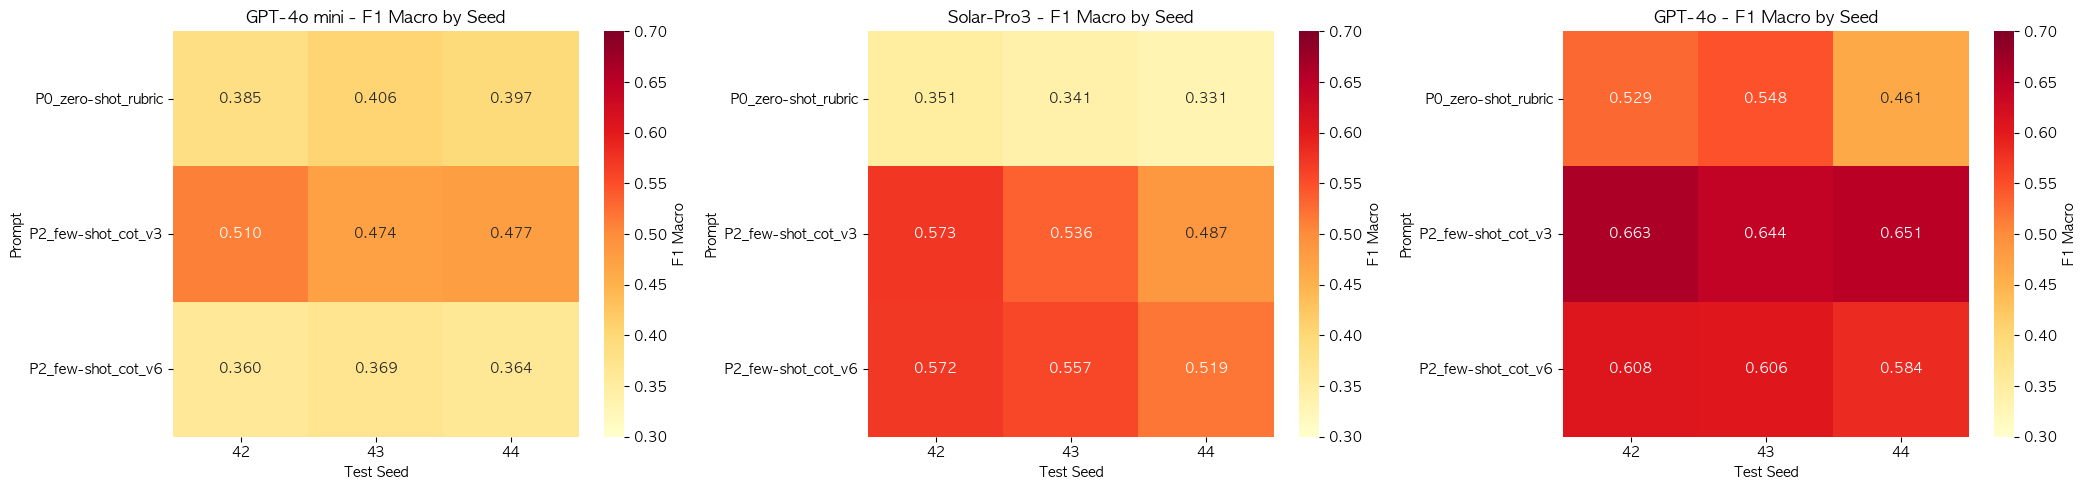

In [3]:
# Seed별 성능 비교 히트맵
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    # 모델 목록: experiment_models가 있으면 사용, 없으면 DataFrame에서 추출
    if 'experiment_models' in globals():
        models = [m.display_name for m in experiment_models]
    else:
        models = reproducibility_df['Model'].unique().tolist()
    
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
    if n_models == 1:
        axes = [axes]
    
    for ax, model in zip(axes, models):
        subset = reproducibility_df[reproducibility_df['Model'] == model]
        pivot = subset.pivot(index='Prompt', columns='Test_Seed', values='F1_Mean')
        
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.3, vmax=0.7,
                    ax=ax, cbar_kws={'label': 'F1 Macro'})
        ax.set_title(f'{model} - F1 Macro by Seed')
        ax.set_xlabel('Test Seed')
        ax.set_ylabel('Prompt')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'summary' / 'generalization_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [4]:
# Seed 간 성능 변동성 분석
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    print("\n[Seed 간 성능 변동성 (Standard Deviation)]")
    
    seed_variance = reproducibility_df.groupby(['Model', 'Prompt'])['F1_Mean'].std().reset_index()
    seed_variance.columns = ['Model', 'Prompt', 'F1_Std_Across_Seeds']
    
    print("\n변동성이 작은 조합 (일반화 우수):")
    print(seed_variance.sort_values('F1_Std_Across_Seeds', ascending=True).head(6).to_string(index=False))
    
    print("\n변동성이 큰 조합:")
    print(seed_variance.sort_values('F1_Std_Across_Seeds', ascending=False).head(6).to_string(index=False))


[Seed 간 성능 변동성 (Standard Deviation)]

변동성이 작은 조합 (일반화 우수):
      Model              Prompt  F1_Std_Across_Seeds
GPT-4o mini  P2_few-shot_cot_v6             0.004845
     GPT-4o  P2_few-shot_cot_v3             0.009493
 Solar-Pro3 P0_zero-shot_rubric             0.010039
GPT-4o mini P0_zero-shot_rubric             0.010607
     GPT-4o  P2_few-shot_cot_v6             0.013236
GPT-4o mini  P2_few-shot_cot_v3             0.020121

변동성이 큰 조합:
      Model              Prompt  F1_Std_Across_Seeds
     GPT-4o P0_zero-shot_rubric             0.045620
 Solar-Pro3  P2_few-shot_cot_v3             0.043275
 Solar-Pro3  P2_few-shot_cot_v6             0.027405
GPT-4o mini  P2_few-shot_cot_v3             0.020121
     GPT-4o  P2_few-shot_cot_v6             0.013236
GPT-4o mini P0_zero-shot_rubric             0.010607


---
## 9. Wide Table (샘플별 3회 예측 비교)

각 샘플에 대해 3회 예측 결과를 나란히 배치하여 불일치 패턴을 분석합니다.
- **Wide Table**: 각 행 = 1개 샘플, 각 열 = Run 1/2/3의 예측값
- 불일치 샘플 분석: 어떤 레이블에서 예측이 불안정한지 확인
- 특히 레이블 3/4/5 경계에서 불일치가 빈번할 것으로 예상

In [5]:
# Wide table 생성 (모델/프롬프트별 샘플별 예측 비교)
if 'all_detailed_predictions' in globals() and all_detailed_predictions:
    detailed_df = pd.DataFrame(all_detailed_predictions)
    
    # Pivot: Run 1/2/3 예측을 컬럼으로
    wide_tables = []
    
    for (model, prompt, seed), group in detailed_df.groupby(['Model', 'Prompt', 'Test_Seed']):
        pivot = group.pivot(
            index='Sample_ID',
            columns='Run',
            values='Y_Pred'
        ).reset_index()
        
        pivot.columns = ['Sample_ID', 'Pred_Run1', 'Pred_Run2', 'Pred_Run3']
        
        # Y_True 추가
        y_true_map = group[group['Run'] == 1].set_index('Sample_ID')['Y_True']
        pivot['Y_True'] = pivot['Sample_ID'].map(y_true_map)
        
        pivot['Model'] = model
        pivot['Prompt'] = prompt
        pivot['Test_Seed'] = seed
        
        # 불일치 계산
        pivot['All_Same'] = (
            (pivot['Pred_Run1'] == pivot['Pred_Run2']) & 
            (pivot['Pred_Run1'] == pivot['Pred_Run3'])
        )
        pivot['All_Correct'] = (
            (pivot['Pred_Run1'] == pivot['Y_True']) & 
            (pivot['Pred_Run2'] == pivot['Y_True']) & 
            (pivot['Pred_Run3'] == pivot['Y_True'])
        )
        
        wide_tables.append(pivot)
    
    wide_df = pd.concat(wide_tables, ignore_index=True)
    
    # 컬럼 순서 정리
    wide_df = wide_df[['Model', 'Prompt', 'Test_Seed', 'Sample_ID', 'Y_True', 
                       'Pred_Run1', 'Pred_Run2', 'Pred_Run3', 'All_Same', 'All_Correct']]
    
    print(f"Wide table: {wide_df.shape}")
    display(wide_df.head(10))
    
    # 저장
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    wide_path = OUTPUT_DIR / 'summary' / f'wide_predictions_{timestamp}.csv'
    wide_df.to_csv(wide_path, index=False, encoding='utf-8-sig')
    print(f"\nWide table 저장: {wide_path}")

In [6]:
# 불일치 샘플 분석
if 'wide_df' in globals():
    print("="*70)
    print("불일치 샘플 분석")
    print("="*70)
    
    # 조합별 불일치 통계
    disagreement_stats = wide_df.groupby(['Model', 'Prompt', 'Test_Seed']).agg({
        'All_Same': lambda x: (~x).sum(),
        'Sample_ID': 'count'
    }).reset_index()
    disagreement_stats.columns = ['Model', 'Prompt', 'Test_Seed', 'N_Disagreement', 'N_Total']
    disagreement_stats['Disagreement_Rate'] = disagreement_stats['N_Disagreement'] / disagreement_stats['N_Total']
    
    print("\n[조합별 불일치 샘플 수]")
    display(disagreement_stats.sort_values('Disagreement_Rate', ascending=False))

불일치 샘플 분석

[조합별 불일치 샘플 수]


,Model,Prompt,Test_Seed,N_Disagreement,N_Total,Disagreement_Rate
19,Solar-Pro3,P0_zero-shot_rubric,43,51,416,0.122596
18,Solar-Pro3,P0_zero-shot_rubric,42,47,416,0.112981
24,Solar-Pro3,P2_few-shot_cot_v6,42,40,416,0.096154
21,Solar-Pro3,P2_few-shot_cot_v3,42,40,416,0.096154
8,GPT-4o,P2_few-shot_cot_v6,44,36,416,0.086538
23,Solar-Pro3,P2_few-shot_cot_v3,44,35,416,0.084135
26,Solar-Pro3,P2_few-shot_cot_v6,44,34,416,0.081731
20,Solar-Pro3,P0_zero-shot_rubric,44,33,416,0.079327
22,Solar-Pro3,P2_few-shot_cot_v3,43,32,416,0.076923
15,GPT-4o mini,P2_few-shot_cot_v6,42,30,416,0.072115


---
## 10. 종합 요약

전체 실험 결과를 요약합니다.
- 최고 성능 조합 (모델 + 프롬프트)
- 재현성 지표 (3회 일치율, Fleiss' Kappa)
- 일반화 지표 (seed 간 성능 변동)
- ML/BERT 대비 LLM의 위치: BERT > ML > LLM 순서

In [7]:
# 종합 요약
if 'reproducibility_df' in globals() and not reproducibility_df.empty:
    print("="*70)
    print("종합 요약")
    print("="*70)
    
    # 1. Model × Prompt 조합별 성능 (핵심)
    print("\n[1] Model × Prompt 조합별 성능 (3-Seed 평균)")
    print("-"*70)
    
    combination_summary = reproducibility_df.groupby(['Model', 'Prompt']).agg({
        'Acc_Mean': ['mean', 'std'],
        'F1_Mean': ['mean', 'std'],
        'Kappa_Mean': ['mean', 'std'],
        'Agreement_Rate': 'mean'
    }).round(4)
    
    combination_summary.columns = ['Acc_Mean', 'Acc_Std', 'F1_Mean', 'F1_Std', 
                                    'Kappa_Mean', 'Kappa_Std', 'Reproducibility']
    combination_summary = combination_summary.reset_index()
    combination_summary = combination_summary.sort_values('F1_Mean', ascending=False)
    
    display(combination_summary)
    
    # 최고 조합
    best = combination_summary.iloc[0]
    print("\n" + "="*70)
    print("★★★ 최고 성능 조합 ★★★")
    print("="*70)
    print(f"\n  Model: {best['Model']}")
    print(f"  Prompt: {best['Prompt']}")
    print(f"  ----------------------------------------")
    print(f"  Accuracy:    {best['Acc_Mean']:.4f} (±{best['Acc_Std']:.4f})")
    print(f"  F1 Macro:    {best['F1_Mean']:.4f} (±{best['F1_Std']:.4f})")
    print(f"  Kappa:       {best['Kappa_Mean']:.4f} (±{best['Kappa_Std']:.4f})")
    print(f"  재현성:      {best['Reproducibility']:.4f}")

종합 요약

[1] Model × Prompt 조합별 성능 (3-Seed 평균)
----------------------------------------------------------------------


,Model,Prompt,Acc_Mean,Acc_Std,F1_Mean,F1_Std,Kappa_Mean,Kappa_Std,Reproducibility
1,GPT-4o,P2_few-shot_cot_v3,0.6247,0.0046,0.6524,0.0095,0.5414,0.0046,0.9535
2,GPT-4o,P2_few-shot_cot_v6,0.6603,0.0217,0.5991,0.0132,0.5664,0.0269,0.9383
8,Solar-Pro3,P2_few-shot_cot_v6,0.6306,0.0410,0.5491,0.0274,0.5382,0.0471,0.9207
7,Solar-Pro3,P2_few-shot_cot_v3,0.5625,0.0360,0.5317,0.0433,0.4643,0.0408,0.9143
0,GPT-4o,P0_zero-shot_rubric,0.6087,0.0390,0.5125,0.0456,0.5032,0.0467,0.9335
4,GPT-4o mini,P2_few-shot_cot_v3,0.4720,0.0028,0.4870,0.0201,0.3594,0.0039,0.9535
3,GPT-4o mini,P0_zero-shot_rubric,0.4615,0.0021,0.3957,0.0106,0.3546,0.0063,0.9567
5,GPT-4o mini,P2_few-shot_cot_v6,0.4605,0.0058,0.3643,0.0048,0.3436,0.0051,0.9423
6,Solar-Pro3,P0_zero-shot_rubric,0.3849,0.0128,0.3409,0.0100,0.2939,0.0113,0.8950



★★★ 최고 성능 조합 ★★★

  Model: GPT-4o
  Prompt: P2_few-shot_cot_v3
  ----------------------------------------
  Accuracy:    0.6247 (±0.0046)
  F1 Macro:    0.6524 (±0.0095)
  Kappa:       0.5414 (±0.0046)
  재현성:      0.9535


In [8]:
# 최종 요약 저장
if 'combination_summary' in globals() and 'best' in globals():
    print("최종 요약 저장 중...")
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # 조합별 요약 저장
    summary_path = OUTPUT_DIR / 'summary' / f'combination_summary_{timestamp}.csv'
    combination_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
    print(f"  - 조합별 요약: {summary_path}")
    
    # 실험 설정 추출 (DataFrame에서 또는 기존 변수에서)
    if 'experiment_models' in globals():
        models_list = [m.display_name for m in experiment_models]
    else:
        models_list = reproducibility_df['Model'].unique().tolist()
    
    if 'prompt_versions' in globals():
        prompts_list = prompt_versions
    else:
        prompts_list = reproducibility_df['Prompt'].unique().tolist()
    
    n_repeats = N_REPEATS if 'N_REPEATS' in globals() else 3
    total_combs = total_combinations if 'total_combinations' in globals() else len(reproducibility_df)
    
    # best에서 값 추출 (안전하게)
    best_model = str(best['Model']) if 'Model' in best.index else str(best.iloc[0])
    best_prompt = str(best['Prompt']) if 'Prompt' in best.index else str(best.iloc[1])
    
    # 실험 설정 저장
    experiment_config = {
        'Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'Seeds': SEEDS,
        'Models': models_list,
        'Prompts': prompts_list,
        'N_Repeats': n_repeats,
        'Total_Combinations': total_combs,
        'Best_Combination': {
            'Model': best_model,
            'Prompt': best_prompt,
            'Accuracy_Mean': float(best['Acc_Mean']),
            'Accuracy_Std': float(best['Acc_Std']),
            'F1_Macro_Mean': float(best['F1_Mean']),
            'F1_Macro_Std': float(best['F1_Std']),
            'Kappa_Mean': float(best['Kappa_Mean']),
            'Reproducibility': float(best['Reproducibility'])
        }
    }
    
    config_path = OUTPUT_DIR / 'summary' / f'experiment_config_{timestamp}.json'
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(experiment_config, f, ensure_ascii=False, indent=2)
    
    print(f"  - 실험 설정: {config_path}")
    print("\n최종 요약 파일 저장 완료!")
else:
    print("[경고] combination_summary 또는 best 변수가 없습니다. cell-29를 먼저 실행하세요.")

최종 요약 저장 중...
  - 조합별 요약: <PROJECT_ROOT>/01_Analysis/03_LLM/results/final_experiment/summary/combination_summary_20260201_104902.csv
  - 실험 설정: <PROJECT_ROOT>/01_Analysis/03_LLM/results/final_experiment/summary/experiment_config_20260201_104902.json

최종 요약 파일 저장 완료!


In [9]:
# 최종 출력
print("\n" + "="*70)
print("LLM 재현성 및 일반화 실험 완료!")
print("="*70)

if 'best' in globals():
    print(f"\n★ 최고 조합: {best['Model']} + {best['Prompt']}")
    print(f"  - F1 Macro: {best['F1_Mean']:.4f} (±{best['F1_Std']:.4f})")
    print(f"  - 재현성: {best['Reproducibility']:.4f}")
    print(f"\n  → 이 조합을 ML, BERT 모델과 비교하세요.")

print(f"\n완료 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


LLM 재현성 및 일반화 실험 완료!

★ 최고 조합: GPT-4o + P2_few-shot_cot_v3
  - F1 Macro: 0.6524 (±0.0095)
  - 재현성: 0.9535

  → 이 조합을 ML, BERT 모델과 비교하세요.

완료 시간: 2026-02-01 10:49:03


---
## 11. 추가 분석: 라벨별 혼동 행렬

프롬프트와 모델 조합별로 어떤 레이블을 가장 많이 혼동하는지 분석합니다.
- **혼동 행렬(Confusion Matrix)**: 실제 레이블(행) vs 예측 레이블(열)의 교차표
- **주요 혼동 패턴**: 레이블 3↔4, 4↔5 간의 혼동이 특히 빈번
  - 3(문제 지적)과 4(해결 방향): "문제 지적"에 암시적 해결이 포함된 경우 혼동
  - 4(해결 방향)과 5(구체적 대안): "구체적"의 기준이 모호하여 혼동
- P9(Hard Tiebreaker) 프롬프트가 이 경계 혼동을 가장 잘 해결함

In [ ]:
from sklearn.metrics import confusion_matrix

# 분석용 데이터 준비 (Run 1, temperature=0이므로 Run 간 차이 최소)
run1_df = detailed_df[(detailed_df['Run'] == 1) & (detailed_df['Y_Pred'] != 'NA')].copy()
run1_df['Y_Pred'] = run1_df['Y_Pred'].astype(int)
LABELS = sorted(run1_df['Y_True'].unique())

print(f"분석 대상: {len(run1_df):,}개 (Run 1, 파싱 성공만)")
print(f"라벨: {LABELS}")


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None,
                          normalize=False, cmap='Blues'):
    """혼동 행렬 시각화"""
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = np.divide(cm, row_sums, where=row_sums != 0,
                               out=np.zeros_like(cm, dtype=float))
        fmt = '.2f'
        title += ' (Normalized)'
    else:
        cm_display = cm
        fmt = 'd'

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    sns.heatmap(cm_display, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    return cm


def get_top_confusions(cm, top_n=10):
    """혼동 행렬에서 가장 많이 혼동된 라벨 쌍 추출 (대각선 제외)"""
    confusions = []
    for i, true_label in enumerate(LABELS):
        for j, pred_label in enumerate(LABELS):
            if i != j and cm[i, j] > 0:
                confusions.append({
                    'True_Label': true_label,
                    'Pred_Label': pred_label,
                    'Count': int(cm[i, j]),
                    'Error_Rate': round(cm[i, j] / cm[i].sum(), 4) if cm[i].sum() > 0 else 0
                })

    conf_df = pd.DataFrame(confusions).sort_values('Count', ascending=False)
    return conf_df.head(top_n)


print("헬퍼 함수 정의 완료")

In [ ]:
# ============================================================
# 11-1. 전체 세트 혼동 행렬 (모든 모델 × 프롬프트 × Seed)
# ============================================================

print("="*70)
print("11-1. 전체 세트 혼동 행렬 (모든 모델 × 프롬프트 × Seed, Run 1)")
print("="*70)
print(f"총 샘플 수: {len(run1_df):,}개")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
cm_overall = plot_confusion_matrix(
    run1_df['Y_True'], run1_df['Y_Pred'],
    title='전체 혼동 행렬 (Count)', ax=axes[0])

# Normalized (row-wise: True label 기준 비율)
plot_confusion_matrix(
    run1_df['Y_True'], run1_df['Y_Pred'],
    title='전체 혼동 행렬', ax=axes[1], normalize=True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'summary' / 'confusion_matrix_overall.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Top 혼동 쌍
print("\n[가장 많이 혼동된 라벨 쌍 (Top 10)]")
top_conf = get_top_confusions(cm_overall, top_n=10)
display(top_conf.reset_index(drop=True))

In [ ]:
# ============================================================
# 11-2. 모델/프롬프트별 혼동 행렬 (필터 설정 가능)
# ============================================================
# 아래 변수를 수정하여 특정 모델/프롬프트만 비교할 수 있습니다.
#   'all' → 전체 표시
#   리스트  → 선택한 것만 표시 (예: ['GPT-4o'])
# ============================================================

FILTER_MODELS  = 'all'   # 'all' 또는 ['GPT-4o', 'Solar-Pro3'] 등
FILTER_PROMPTS = 'all'   # 'all' 또는 ['P2_few-shot_cot_v3'] 등
NORMALIZE = True          # True: 비율(row-wise), False: 빈도수

# ============================================================

# 필터 적용
filtered_df = run1_df.copy()
if FILTER_MODELS != 'all':
    filtered_df = filtered_df[filtered_df['Model'].isin(FILTER_MODELS)]
if FILTER_PROMPTS != 'all':
    filtered_df = filtered_df[filtered_df['Prompt'].isin(FILTER_PROMPTS)]

models = sorted(filtered_df['Model'].unique())
prompts = sorted(filtered_df['Prompt'].unique())

print(f"선택된 모델: {models}")
print(f"선택된 프롬프트: {prompts}")
print(f"총 샘플 수: {len(filtered_df):,}개\n")

n_rows, n_cols = len(prompts), len(models)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 5 * n_rows),
                         squeeze=False)

for i, prompt in enumerate(prompts):
    for j, model in enumerate(models):
        subset = filtered_df[
            (filtered_df['Model'] == model) & (filtered_df['Prompt'] == prompt)]

        if len(subset) > 0:
            plot_confusion_matrix(
                subset['Y_True'], subset['Y_Pred'],
                title=f'{model}\n{prompt}',
                ax=axes[i, j], normalize=NORMALIZE)
        else:
            axes[i, j].text(0.5, 0.5, '데이터 없음',
                            ha='center', va='center', fontsize=14)
            axes[i, j].set_title(f'{model}\n{prompt}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'summary' / 'confusion_matrix_by_model_prompt.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 11-3. 모델/프롬프트별 Top 혼동 쌍 비교표
# ============================================================

print("="*70)
print("11-3. 모델/프롬프트별 Top 5 혼동 쌍")
print("="*70)

all_top_confusions = []

for model in sorted(run1_df['Model'].unique()):
    for prompt in sorted(run1_df['Prompt'].unique()):
        subset = run1_df[
            (run1_df['Model'] == model) & (run1_df['Prompt'] == prompt)]
        if len(subset) == 0:
            continue

        cm = confusion_matrix(subset['Y_True'], subset['Y_Pred'], labels=LABELS)
        top = get_top_confusions(cm, top_n=5)
        top['Model'] = model
        top['Prompt'] = prompt
        all_top_confusions.append(top)

top_conf_all = pd.concat(all_top_confusions, ignore_index=True)
top_conf_all = top_conf_all[['Model', 'Prompt', 'True_Label', 'Pred_Label',
                              'Count', 'Error_Rate']]

# 모델별로 출력
for model in sorted(top_conf_all['Model'].unique()):
    print(f"\n{'─'*60}")
    print(f"  {model}")
    print(f"{'─'*60}")
    model_data = top_conf_all[top_conf_all['Model'] == model]
    display(model_data.reset_index(drop=True))

In [ ]:
# ============================================================
# 11-4. 라벨별 혼동 빈도 요약 (어떤 라벨이 전반적으로 가장 어려운지)
# ============================================================

print("="*70)
print("11-4. 라벨별 오분류 빈도 요약")
print("="*70)

# 모델/프롬프트별 라벨별 정확도
label_acc_records = []
for model in sorted(run1_df['Model'].unique()):
    for prompt in sorted(run1_df['Prompt'].unique()):
        subset = run1_df[
            (run1_df['Model'] == model) & (run1_df['Prompt'] == prompt)]
        if len(subset) == 0:
            continue
        for label in LABELS:
            label_data = subset[subset['Y_True'] == label]
            if len(label_data) == 0:
                continue
            acc = (label_data['Y_Pred'] == label).mean()
            label_acc_records.append({
                'Model': model, 'Prompt': prompt,
                'Label': label, 'N': len(label_data),
                'Accuracy': round(acc, 4)
            })

label_acc_df = pd.DataFrame(label_acc_records)

# 히트맵: 모델+프롬프트 조합 × 라벨 → 정확도
label_acc_df['Combination'] = label_acc_df['Model'] + '\n' + label_acc_df['Prompt']

pivot = label_acc_df.pivot(index='Combination', columns='Label', values='Accuracy')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'Per-Label Accuracy'})
ax.set_title('모델/프롬프트 조합별 라벨 정확도', fontsize=13, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'summary' / 'per_label_accuracy_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 라벨별 평균 정확도 (전 조합 평균)
print("\n[라벨별 평균 정확도 (전 모델/프롬프트 평균)]")
label_mean = label_acc_df.groupby('Label')['Accuracy'].agg(['mean', 'std']).round(4)
label_mean.columns = ['Acc_Mean', 'Acc_Std']
display(label_mean)